In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from ocularrigidity.data.measurements.dataframe import load_measurements
from ocularrigidity.scripts.pulsation.infer import ROOT_ONE_CYCLE

index = 0
df = load_measurements(include_HR=True)
video = Path(df.iloc[index]["MeasureValue"]).as_posix().replace("\\", "/")


In [ ]:
from ocularrigidity.data.consts import CHECKPOINT_PATH
from ocularrigidity.segmentation.trainer.pl_module import ChoroidSegmentationModule

model = ChoroidSegmentationModule.load_from_checkpoint(CHECKPOINT_PATH).cuda()


DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.


In [ ]:
from ocularrigidity.data.compression import read_gray
from ocularrigidity.segmentation.inference import infer

data = read_gray(ROOT_ONE_CYCLE / video / "one_cycle.mkv")
masks = infer(
    model,
    data,
    batch_size=16,
    scale_factor=(1.0, 1.0),
    return_logit=False,
    use_graphcut=True,
    use_amp=True,
    verbose=True,
    graphcut_kwargs=dict(
        temporal_smooth=True,
        temporal_iterations=4,
        temporal_mu=1.0,
        temporal_sigma=2.0,
        lambda_smooth=1.0,
    ),
)

Inference:   0%|          | 0/5 [00:00<?, ?it/s]

Processing Frames:   0%|          | 0/75 [00:00<?, ?it/s]

In [63]:
from ocularrigidity.segmentation.vessels.traditional import niblack_vessels
from ocularrigidity.segmentation.vessels.postprocess import (
    morph_open,
    remove_small_objects,
)

vessels_masks = niblack_vessels(data, masks, window_size=155, k=0.8, verbose=True)

vessels_masks = morph_open(vessels_masks, kernel_size=5, iterations=1)
vessels_masks = remove_small_objects(vessels_masks, min_size=500)

  0%|          | 0/75 [00:00<?, ?it/s]

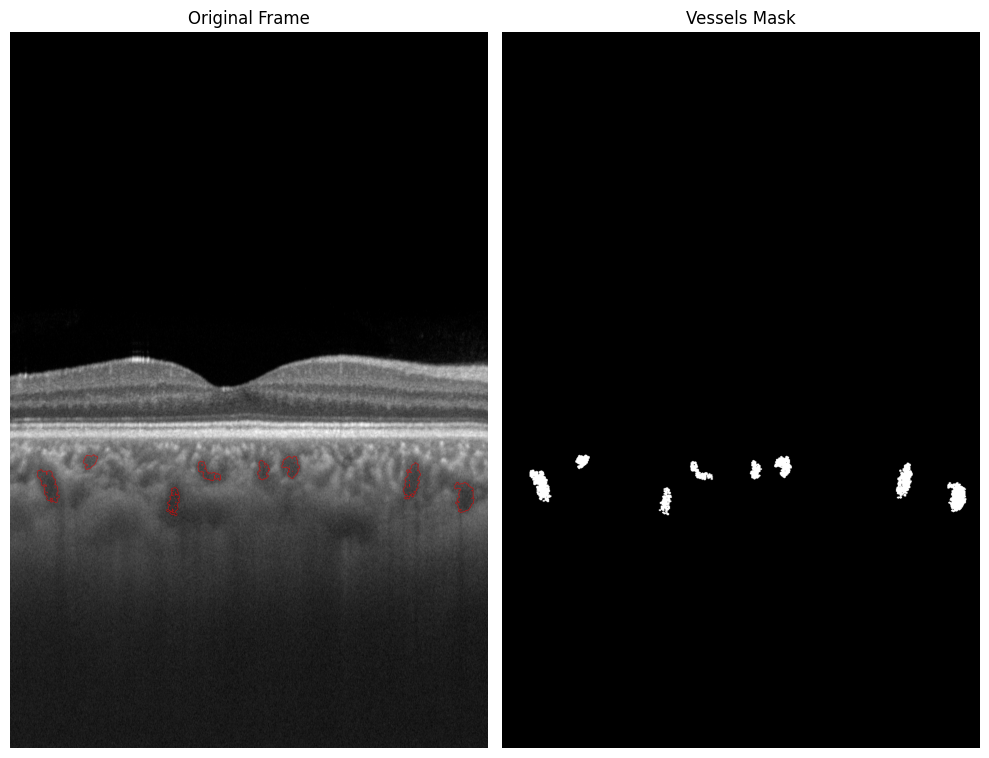

In [64]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

frame_index = 1
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].imshow(data[frame_index], cmap="gray")
axes[0].set_title("Original Frame")
axes[0].axis("off")

axes[0].contour(vessels_masks[frame_index], colors="red", linewidths=0.1, alpha=0.5)

axes[1].imshow(vessels_masks[frame_index], cmap="gray")
axes[1].set_title("Vessels Mask")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [65]:
import matplotlib.pyplot as plt
import cv2

In [ ]:
from choroid_pulse import simulate_choroid_pulsation


In [66]:
masks_sim = simulate_choroid_pulsation(
    masks[0], vessels_masks, mesh_step=2, verbose=True
)


DOFs total/free/constrained: 788994/87786/701208
Factorizing K_ff once...
  frame 7/74
  frame 14/74
  frame 21/74
  frame 28/74
  frame 35/74
  frame 42/74
  frame 49/74
  frame 56/74
  frame 63/74
  frame 70/74


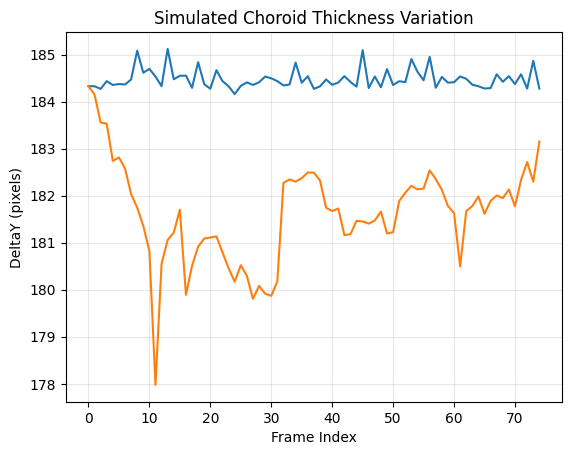

In [68]:
from ocularrigidity.rigidity.features import extract_deltaY_naive


synthetic_thickness = extract_deltaY_naive(masks_sim)
measured_thickness = extract_deltaY_naive(masks)
plt.plot(synthetic_thickness.mean(axis=1))
plt.plot(measured_thickness.mean(axis=1))
plt.title("Simulated Choroid Thickness Variation")
plt.xlabel("Frame Index")
plt.ylabel("DeltaY (pixels)")
plt.grid(alpha=0.3)
plt.show()